In [1]:
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
from scipy import stats
from scipy.stats.contingency import chi2_contingency
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from statsmodels.graphics.gofplots import qqplot
import math
print("Setup Complete")

Setup Complete


In [2]:
df = pd.read_csv("HR_employee_attrition_staging.csv")
print(df.head())
print(df.tail())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome      Education EducationField  EmployeeCount  \
0                 1        College  Life Sciences              1   
1                 8  Below College  Life Sciences              1   
2                 2        College          Other              1   
3                 3         Master  Life Sciences              1   
4                 2  Below College        Medical              1   

   EmployeeNumber  ... RelationshipSatisfaction StandardHours  \
0               1  ...                      Low            80   
1               

In [6]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
columnList = df.columns.tolist()
print(len(columnList))
for i in columnList:
    print(i)

35
Age
Attrition
BusinessTravel
DailyRate
Department
DistanceFromHome
Education
EducationField
EmployeeCount
EmployeeNumber
EnvironmentSatisfaction
Gender
HourlyRate
JobInvolvement
JobLevel
JobRole
JobSatisfaction
MaritalStatus
MonthlyIncome
MonthlyRate
NumCompaniesWorked
Over18
OverTime
PercentSalaryHike
PerformanceRating
RelationshipSatisfaction
StandardHours
StockOptionLevel
TotalWorkingYears
TrainingTimesLastYear
WorkLifeBalance
YearsAtCompany
YearsInCurrentRole
YearsSinceLastPromotion
YearsWithCurrManager


In [17]:
#display column
df.Education

0       2
1       1
2       2
3       4
4       1
       ..
1465    2
1466    1
1467    3
1468    3
1469    3
Name: Education, Length: 1470, dtype: int64

In [13]:
#get null values
df.loc[df.DistanceFromHome.isnull()]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [82]:
#get distinct values
arr1 = df.YearsWithCurrManager.unique()
print(arr1)
arr = df.DistanceFromHome.sort_values().unique()
print(arr)

[ 5  7  0  2  6  8  3 11 17  1  4 12  9 10 15 13 16 14]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29]


In [16]:
# check for values under zero
df.loc[df.DistanceFromHome < 0]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager


In [83]:
#CHECK IS THERE'S POSSIBLE OUTLIERS WITH KURTOSIS
exc_kurtosis = stats.kurtosis(df["YearsWithCurrManager"], fisher=True)
print(f"Excess kurtosis {exc_kurtosis.round(2)}")
raw_kurtosis = stats.kurtosis(df["YearsWithCurrManager"], fisher=False)
print(f"Raw kurtosis {raw_kurtosis.round(2)}")

Excess kurtosis 0.17
Raw kurtosis 3.17


In [84]:
#CHECK OUTLIERS WITH Z-SCORE
df["z_score"] = stats.zscore(df["YearsWithCurrManager"])
outliers = df[df["z_score"].abs() > 3]
print(outliers)

      Age Attrition BusinessTravel  DailyRate              Department  \
28     44        No  Travel_Rarely        477  Research & Development   
123    51        No  Travel_Rarely        684  Research & Development   
153    45        No  Travel_Rarely        194  Research & Development   
187    55        No  Travel_Rarely        692  Research & Development   
231    42        No  Travel_Rarely        532  Research & Development   
386    37        No  Travel_Rarely       1107  Research & Development   
561    52        No  Travel_Rarely        621                   Sales   
616    51        No  Travel_Rarely       1318                   Sales   
635    35        No  Travel_Rarely        607  Research & Development   
686    41        No  Travel_Rarely        263  Research & Development   
875    44        No  Travel_Rarely        200  Research & Development   
926    43        No  Travel_Rarely        531                   Sales   
1078   44        No  Travel_Rarely        136  Rese

In [85]:
Q1 = df["YearsWithCurrManager"].quantile(.25)
Q3 = df["YearsWithCurrManager"].quantile(.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5*(IQR)
upper_bound = Q3 + 1.5*(IQR)
print(upper_bound)

outliers = df[(df["YearsWithCurrManager"] < lower_bound) | (df["YearsWithCurrManager"] > upper_bound)]
print(outliers["YearsWithCurrManager"])

14.5
28      17
123     15
153     15
187     15
231     15
386     17
561     16
616     17
635     15
686     17
875     17
926     17
1078    17
1348    16
Name: YearsWithCurrManager, dtype: int64


In [56]:
df_clean = df[~((df["StockOptionLevel"] >= 3) & (df["TotalWorkingYears"]<=6))]
df_clean[df_clean['TotalWorkingYears'] == 1]

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
17,22,No,Non-Travel,1123,Research & Development,16,2,Medical,1,22,...,2,80,2,1,2,2,1,0,0,0
40,35,No,Travel_Rarely,464,Research & Development,4,2,Other,1,53,...,3,80,1,1,3,3,1,0,0,0
41,27,No,Travel_Rarely,1240,Research & Development,2,4,Life Sciences,1,54,...,4,80,1,1,6,3,1,0,0,0
42,26,Yes,Travel_Rarely,1357,Research & Development,25,3,Life Sciences,1,55,...,3,80,0,1,2,2,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1339,22,Yes,Travel_Rarely,391,Research & Development,7,1,Life Sciences,1,1878,...,1,80,0,1,2,3,1,0,0,0
1349,26,No,Travel_Rarely,482,Research & Development,1,2,Life Sciences,1,1893,...,3,80,1,1,3,2,1,0,1,0
1365,29,Yes,Travel_Frequently,746,Sales,24,3,Technical Degree,1,1928,...,4,80,0,1,3,3,1,0,0,0
1379,27,Yes,Travel_Frequently,1337,Human Resources,22,3,Human Resources,1,1944,...,1,80,0,1,2,3,1,0,0,0


In [6]:
print(df.Age.describe())
print(f"Mode: {df.Age.mode()}")

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64
Mode: 0    35
Name: Age, dtype: int64


In [3]:
mean = df.Age.mean()
stddev = df.Age.std()

cv = (stddev/mean)*100
print(cv.round(2))

24.74


In [3]:
attritionDatabase = df.loc[df["Attrition"] == "Yes"]

print(attritionDatabase.loc[attritionDatabase["Department"] == "Sales", "YearsAtCompany"].describe())
print(f"Mode: {attritionDatabase['YearsAtCompany'].mode()}")

count    92.00000
mean      5.51087
std       5.91607
min       0.00000
25%       1.00000
50%       3.50000
75%       8.00000
max      32.00000
Name: YearsAtCompany, dtype: float64
Mode: 0    1
Name: YearsAtCompany, dtype: int64


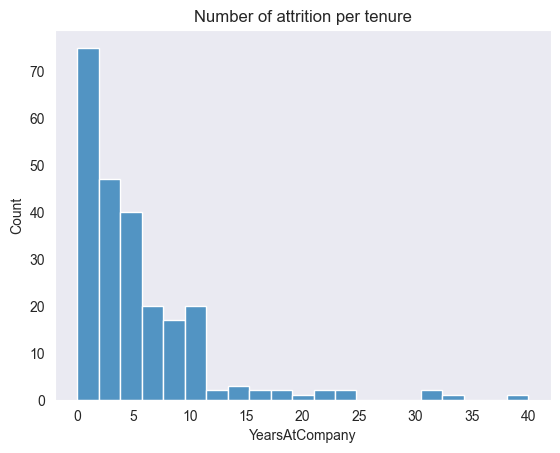

In [38]:
plt.title("Number of attrition per tenure")
sns.histplot(attritionDatabase["YearsAtCompany"])
sns.set_style("dark")

Department
Research & Development    133
Sales                      92
Human Resources            12
Name: count, dtype: int64


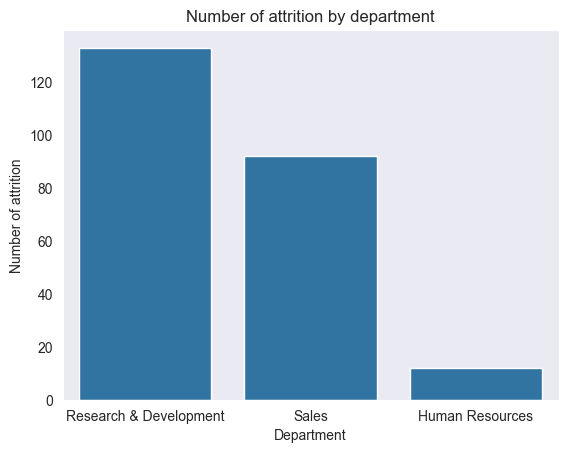

In [37]:
print(attritionDatabase["Department"].value_counts())

plt.title("Number of attrition by department")

sns.countplot(data=attritionDatabase,x="Department",order=attritionDatabase["Department"].value_counts().index)

plt.ylabel("Number of attrition")
sns.set_style("dark")

YearsAtCompany
1     38
10    14
2     13
5     13
4     11
0      9
3      8
7      8
9      4
6      4
8      4
22     1
40     1
31     1
17     1
13     1
18     1
33     1
Name: count, dtype: int64


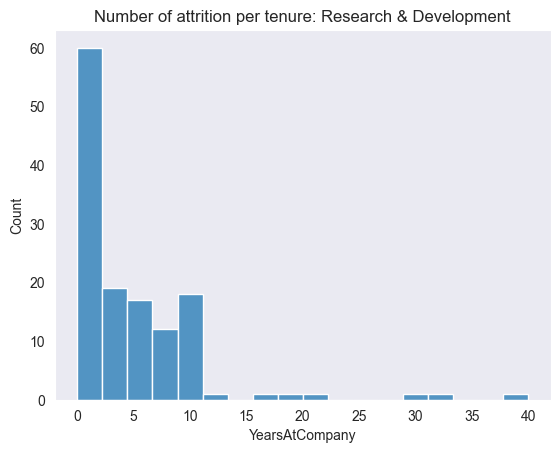

In [42]:
print(attritionDatabase.loc[df["Department"] == "Research & Development", "YearsAtCompany"].value_counts())

plt.title("Number of attrition per tenure: Research & Development")
sns.histplot(attritionDatabase.loc[df["Department"] == "Research & Development", "YearsAtCompany"])
sns.set_style("dark")

YearsAtCompany
1     17
2     12
3     10
5      7
0      7
4      7
6      5
8      5
9      4
10     4
7      2
14     2
11     2
16     1
32     1
21     1
24     1
19     1
15     1
13     1
23     1
Name: count, dtype: int64


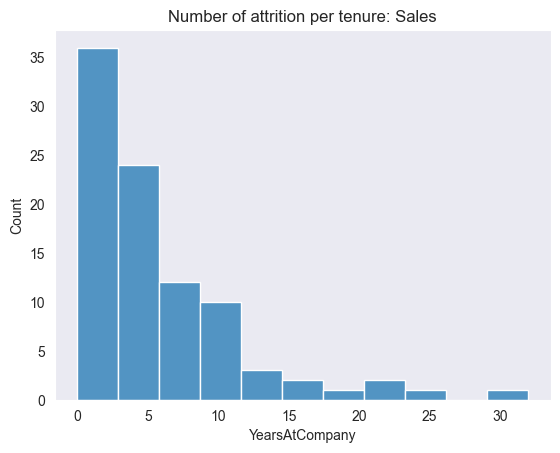

In [44]:
print(attritionDatabase.loc[df["Department"] == "Sales", "YearsAtCompany"].value_counts())

plt.title("Number of attrition per tenure: Sales")
sns.histplot(attritionDatabase.loc[df["Department"] == "Sales", "YearsAtCompany"])
sns.set_style("dark")

YearsAtCompany
1     4
3     2
2     2
7     1
20    1
4     1
5     1
Name: count, dtype: int64


<Axes: title={'center': 'Number of attrition per tenure: Human Resources'}, xlabel='YearsAtCompany', ylabel='Count'>

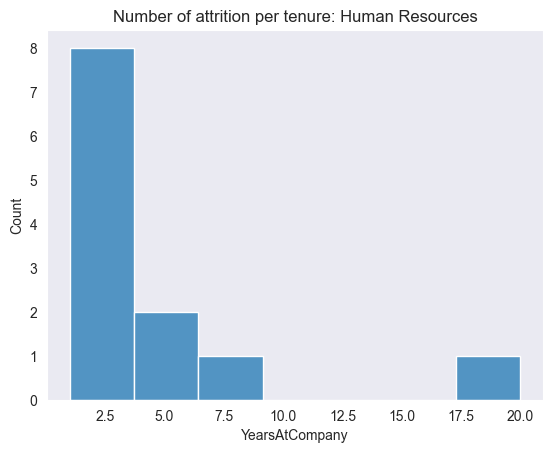

In [45]:
print(attritionDatabase.loc[df["Department"] == "Human Resources", "YearsAtCompany"].value_counts())

plt.title("Number of attrition per tenure: Human Resources")
sns.histplot(attritionDatabase.loc[df["Department"] == "Human Resources", "YearsAtCompany"])

[41 37 28 36 34 32 39 24 50 26 48 46 20 25 56 31 58 19 51 35 38 29 30 33
 47 44 18 52 21 40 22 27 45 42 55 23 49 43 53]
Age
31    18
29    18
28    14
26    12
33    12
32    11
35    10
34     9
30     9
24     7
41     6
37     6
36     6
39     6
20     6
25     6
19     6
44     6
21     6
50     5
58     5
40     5
22     5
46     4
18     4
23     4
56     3
47     3
52     3
27     3
55     3
48     2
51     2
38     2
45     2
42     2
49     2
43     2
53     2
Name: count, dtype: int64


<Axes: title={'center': 'Attrition by age'}, xlabel='Age', ylabel='Count'>

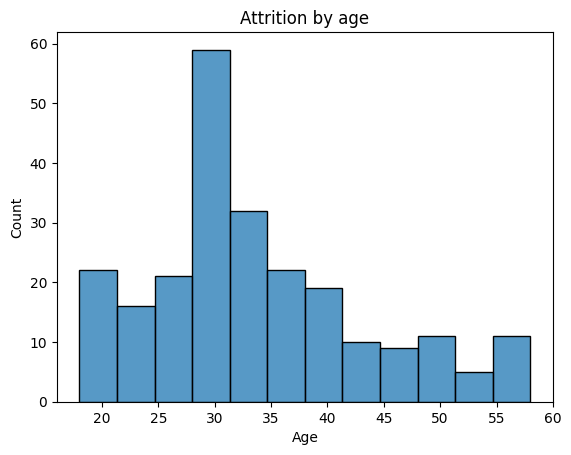

In [4]:
print(attritionDatabase["Age"].unique())
print(attritionDatabase["Age"].value_counts())

plt.title("Attrition by age")
sns.histplot(attritionDatabase["Age"])

[ 8  7  6 10 19  3  1 23  2  9 12 40  0  4 18 17 14 13  5 11 15 24 16 22
 33 21 26 31 20 28 34 25]
TotalWorkingYears
1     40
10    25
6     22
7     18
8     16
5     16
4     12
9     10
3      9
2      9
11     7
12     5
0      5
15     5
18     4
14     4
19     3
17     3
13     3
24     3
16     3
23     2
40     2
22     2
20     2
33     1
21     1
26     1
31     1
28     1
34     1
25     1
Name: count, dtype: int64


<Axes: title={'center': 'Attrition by years worked'}, xlabel='TotalWorkingYears', ylabel='Count'>

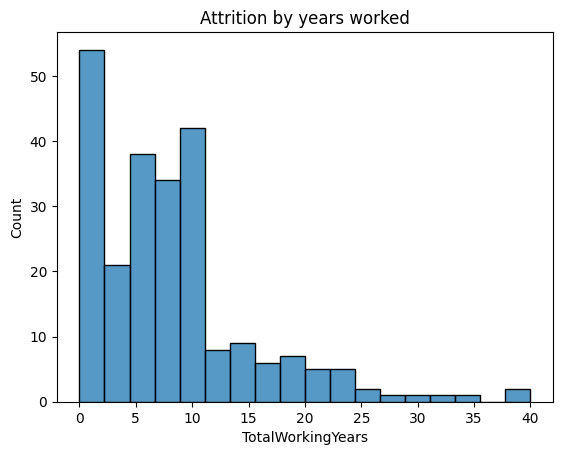

In [7]:
print(attritionDatabase["TotalWorkingYears"].unique())
print(attritionDatabase["TotalWorkingYears"].value_counts())

plt.title("Attrition by years worked")
sns.histplot(attritionDatabase["TotalWorkingYears"])

C:\Users\Jali\AppData\Local\Temp\ipykernel_8284\657884339.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(attritionDatabase["Age"], shade=True)


<Axes: xlabel='Age', ylabel='Density'>

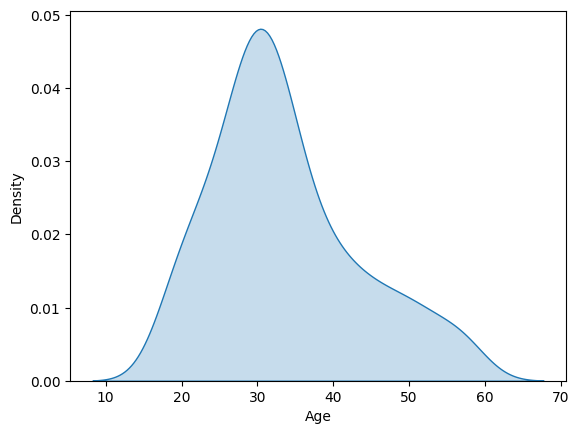

In [16]:
sns.kdeplot(attritionDatabase["Age"], shade=True)


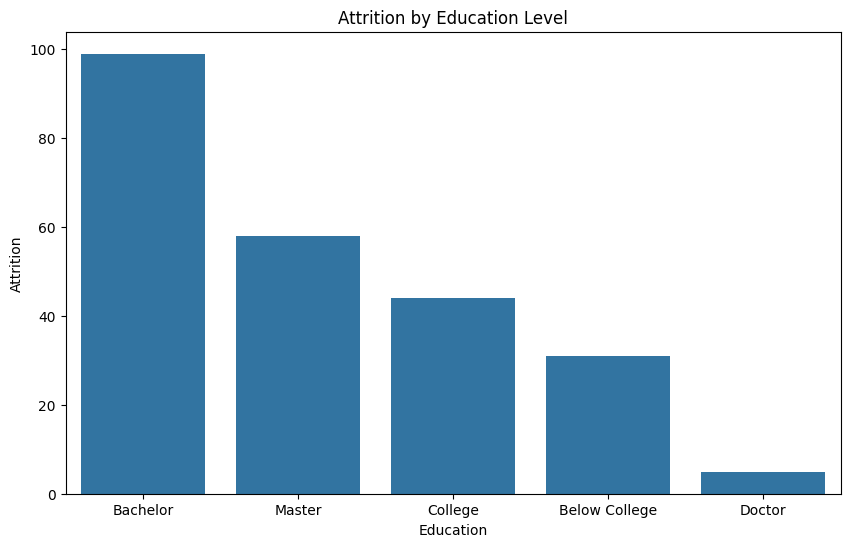

In [34]:
plt.figure(figsize=(10,6))
plt.title("Attrition by Education Level")
sns.countplot(data=attritionDatabase, x="Education", order=df["Education"].value_counts().index)
plt.ylabel("Attrition")

plt.show()

In [5]:
alpha = 0.05
variables = ["Education", "EnvironmentSatisfaction", "JobInvolvement", "JobSatisfaction", "PerformanceRating", "RelationshipSatisfaction", "WorkLifeBalance"]

bonferroni_threshold = alpha/len(variables)

rows = []
for var in variables:
    chi2,pvalue,dof,_= stats.chi2_contingency(pd.crosstab(df[var],df["Attrition"]))
    rows.append({"Variable": var, "Chi2": chi2, "P_Value": pvalue, "DOF": dof})

results_df = pd.DataFrame(rows)
results_df["Significant"]=results_df["P_Value"] < bonferroni_threshold

print(f"Bonferroni threshold: {bonferroni_threshold:.4f}\n")
print(results_df.round(2))

Bonferroni threshold: 0.0071

                   Variable   Chi2  P_Value  DOF  Significant
0                 Education   3.07     0.55    4        False
1   EnvironmentSatisfaction  22.50     0.00    3         True
2            JobInvolvement  28.49     0.00    3         True
3           JobSatisfaction  17.51     0.00    3         True
4         PerformanceRating   0.00     0.99    1        False
5  RelationshipSatisfaction   5.24     0.15    3        False
6           WorkLifeBalance  16.33     0.00    3         True


In [11]:
observed = pd.crosstab(df["Attrition"],df["WorkLifeBalance"])

chi2, pvalue, dof, expected_values = stats.chi2_contingency(observed)
print(expected_values)
if pvalue <= alpha:
    print("There is a significant association")
else:
    print("There is no significant association")

[[ 67.10204082 128.33265306 749.02653061 288.53877551]
 [ 12.89795918  24.66734694 143.97346939  55.46122449]]
There is a significant association


In [12]:
residuals = observed.values
standardised_residuals = (residuals - expected_values)/np.sqrt(expected_values)

residuals_df = pd.DataFrame(
    standardised_residuals,
    index=observed.index,
    columns=observed.columns
).round(2)

print(residuals_df)

WorkLifeBalance   Bad  Best  Better  Good
Attrition                                
No              -1.48 -0.21    0.62 -0.15
Yes              3.37  0.47   -1.41  0.34


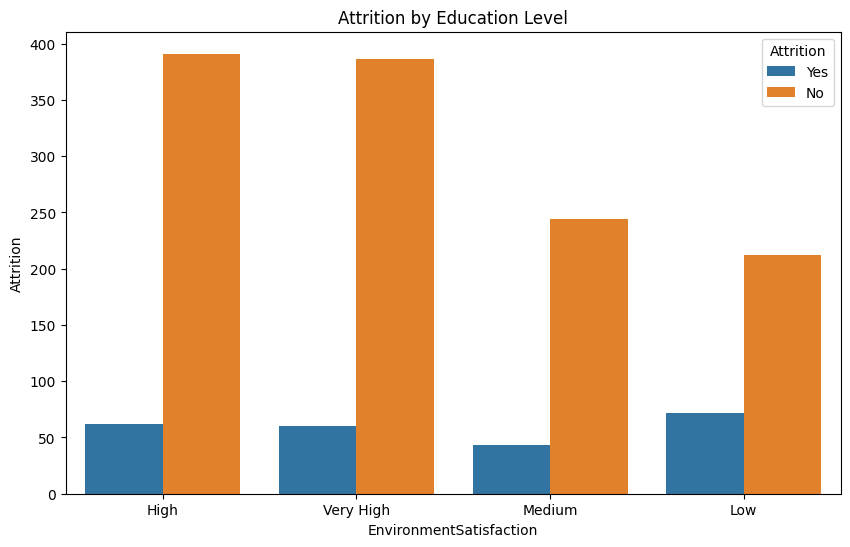

In [7]:
plt.figure(figsize=(10,6))
plt.title("Attrition by Education Level")
sns.countplot(data=df, x="EnvironmentSatisfaction", hue="Attrition", order=df["EnvironmentSatisfaction"].value_counts().index)
plt.ylabel("Attrition")

plt.show()

In [13]:
print(f"Research & Development: {((attritionDatabase.loc[attritionDatabase["Department"]=="Research & Development", "Age"].count()/
      df.loc[df["Department"]=="Research & Development", "Age"].count()) * 100).round(2)}")
print(f"Sales: {((attritionDatabase.loc[attritionDatabase["Department"]=="Sales", "Age"].count()/
      df.loc[df["Department"]=="Sales", "Age"].count()) * 100).round(2)}")
print(f"Human Resources: {((attritionDatabase.loc[attritionDatabase["Department"]=="Human Resources", "Age"].count()/
      df.loc[df["Department"]=="Human Resources", "Age"].count()) * 100).round(2)}")

Research & Development: 13.84
Sales: 20.63
Human Resources: 19.05


C:\Users\Jali\AppData\Local\Temp\ipykernel_16736\634035222.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=attritionDatabase["YearsAtCompany"], shade=True)


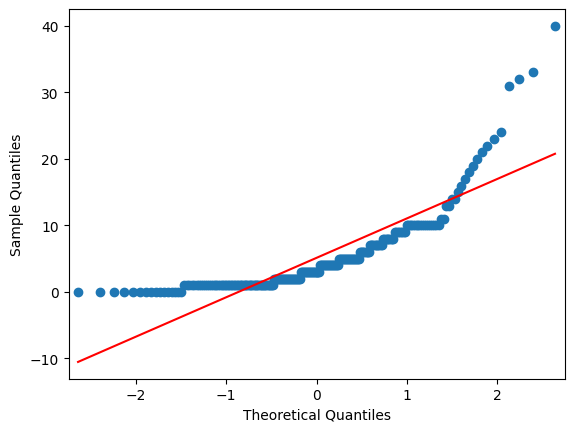

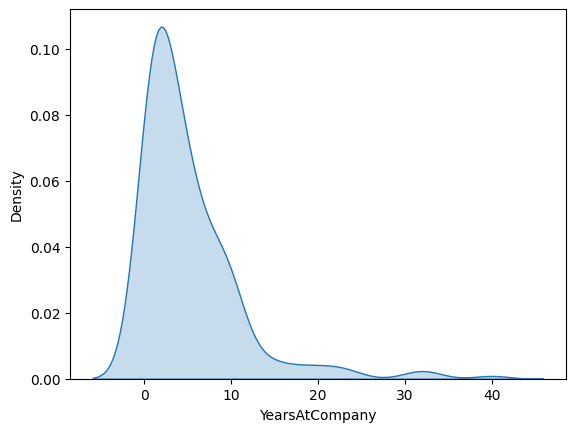

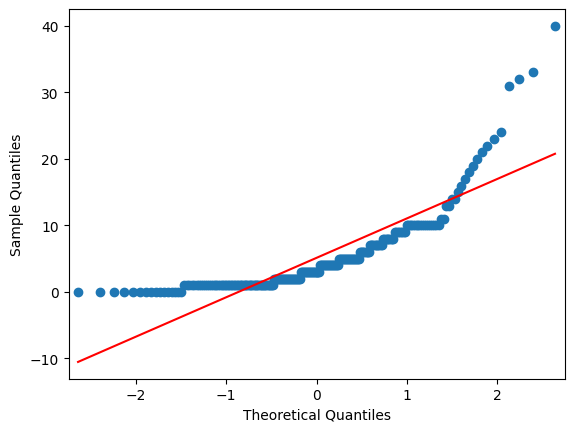

In [7]:
sns.kdeplot(data=attritionDatabase["YearsAtCompany"], shade=True)
qqplot(attritionDatabase["YearsAtCompany"], line="s")

In [ ]:
# Statistical Normality Tests

stat, pvalue = stats.shapiro(df["DailyRate"])
if pvalue <= 0.05:
    print("Shapiro-Wilk says: Not a Gaussian distribution")
else:
    print("Shapiro-Wilk says: It is a Gaussian distribution")
    
stat, pvalue = stats.normaltest(df["DailyRate"])
if pvalue <= 0.05:
    print("D\'Agostino says: Not a Gaussian distribution")   
else:
    print("D\'Agotino says: A Gaussian distribution")
    
print("Anderson-Darling says:")
result = stats.anderson(df["DailyRate"])
for i in range(len(result.critical_values)):
    sl, cv = result.significance_level[i], result.critical_values[i]
    if result.statistic < result.critical_values[i]:
        print("A Gaussian distribution")
    else:
        print("Not a Gaussian distribution")

Shapiro-Wilk says: Not a Gaussian distribution
D'Agostino says: Not a Gaussian distribution
Anderson-Darling says:
Not a Gaussian distribution
Not a Gaussian distribution
Not a Gaussian distribution
Not a Gaussian distribution
Not a Gaussian distribution


C:\Users\Jali\AppData\Local\Temp\ipykernel_15692\3908760240.py:17: FutureWarning: As of SciPy 1.17, users must choose a p-value calculation method by providing the `method` parameter. `method='interpolate'` interpolates the p-value from pre-calculated tables; `method` may also be an instance of `MonteCarloMethod` to approximate the p-value via Monte Carlo simulation. When `method` is specified, the result object will include a `pvalue` attribute and not attributes `critical_value`, `significance_level`, or `fit_result`. Beginning in 1.19.0, these other attributes will no longer be available, and a p-value will always be computed according to one of the available `method` options.
  result = stats.anderson(df["DailyRate"])


In [25]:
df["WorkLifeBalance"]=df["WorkLifeBalance"].replace({1: "Bad", 2: "Good", 3: "Better", 4: "Best"})

In [27]:
df.to_csv("HR_employee_attrition_staging.csv", index=False)